In [1]:
from pathlib import Path
import json, re, pickle
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "Z001_Results_Analizer":
    ROOT = ROOT.parent

# ── Mesh node count cache ─────────────────────────────────────────────────────
_mesh_node_cache = {}

def mesh_node_count(mesh_file):
    """Return number of nodes in a mesh JSON file (cached)."""
    if mesh_file in _mesh_node_cache:
        return _mesh_node_cache[mesh_file]
    mesh_path = ROOT / mesh_file
    if not mesh_path.exists():
        return None
    with mesh_path.open() as f:
        d = json.load(f)
    count = len(d.get("nodes", []))
    _mesh_node_cache[mesh_file] = count
    return count

# ── Auto-discover simulations from OBJ files ──────────────────────────────────
# Groups by: series (100s / 200s)  →  node count  →  stab factor  →  sim number

def parse_obj(sim):
    """Return (mesh_label, stab_label) from OBJ file, or None if file missing."""
    obj_path = ROOT / "I001_Results" / "OBJ_files" / f"SIM_{sim:03d}.json"
    if not obj_path.exists():
        return None
    with obj_path.open() as f:
        d = json.load(f)
    mesh_file = d.get("input_name", "")
    n_nodes = mesh_node_count(mesh_file)
    mesh_label = f"{n_nodes} nodes" if n_nodes is not None else Path(mesh_file).stem
    # Stab factor from Step-0 solver string (stabilise step)
    stab = None
    for step in d.get("steps", []):
        m = re.search(r"factor=([\d.e+\-]+)", step.get("solver", ""))
        if m:
            stab = float(m.group(1))
            break
    stab_label = f"stab={stab:.2e}" if stab is not None else "unknown"
    return mesh_label, stab_label


def build_series(sim_range):
    """Build {mesh_label: {stab_label: sim_num}} for a range of sim numbers."""
    groups = {}
    for sim in sim_range:
        result = parse_obj(sim)
        if result is None:
            continue
        mesh_label, stab_label = result
        groups.setdefault(mesh_label, {})[stab_label] = sim
    return groups


SERIES = {
    "Random mesh (500s)":         build_series(range(500, 554)),
    "Hexagonal packing (600s)":   build_series(range(600, 654)),
}

# ── Print summary ─────────────────────────────────────────────────────────────
import pandas as pd

rows = []
for series_name, mesh_dict in SERIES.items():
    for mesh_label, stab_dict in sorted(mesh_dict.items()):
        for stab_label, sim in sorted(stab_dict.items()):
            rows.append({"series": series_name, "mesh": mesh_label, "stab": stab_label, "sim": sim})

display(pd.DataFrame(rows))


,series,mesh,stab,sim
0,Random mesh (500s),174705 nodes,stab=2.00e-05,515
1,Random mesh (500s),20121 nodes,stab=2.00e-05,512
2,Random mesh (500s),40072 nodes,stab=2.00e-05,513
3,Random mesh (500s),4978 nodes,stab=2.00e-05,510
4,Random mesh (500s),80012 nodes,stab=2.00e-05,514
5,Random mesh (500s),9936 nodes,stab=2.00e-05,511
6,Hexagonal packing (600s),160097 nodes,stab=2.00e-05,615
7,Hexagonal packing (600s),20318 nodes,stab=2.00e-05,612
8,Hexagonal packing (600s),39775 nodes,stab=2.00e-05,613
9,Hexagonal packing (600s),4972 nodes,stab=2.00e-05,610


dict_keys(['source_file', 'source_files', 't', 'time_variant', 'time_invariant', 'general_information', 'eta', 'edge_sizes', 'q', 'epsilon', 'F', 'shear', 'gle', 'shear_mean', 'gle_mean', 'edi', 'edi_mean', 'J', 'C', 'w', 'w_mean', 'w_std', 'w_cv', 'w_std_area_weighted', 'w_cv_area_weighted', 'W'])
dict_keys(['source_file', 'source_files', 't', 'time_variant', 'time_invariant', 'general_information', 'eta', 'edge_sizes', 'q', 'epsilon', 'F', 'shear', 'gle', 'shear_mean', 'gle_mean', 'edi', 'edi_mean', 'J', 'C', 'w', 'w_mean', 'w_std', 'w_cv', 'w_std_area_weighted', 'w_cv_area_weighted', 'W'])
File /Disk_F/FOAM_V03/I001_Results/DATA_PICK_513_T2_003.pkl does not exist
File /Disk_F/FOAM_V03/I001_Results/DATA_PICK_513_T2_004.pkl does not exist
File /Disk_F/FOAM_V03/I001_Results/DATA_PICK_513_T2_005.pkl does not exist
dict_keys(['source_file', 'source_files', 't', 'time_variant', 'time_invariant', 'general_information', 'eta', 'edge_sizes', 'q', 'epsilon', 'F', 'shear', 'gle', 'shear_mean',

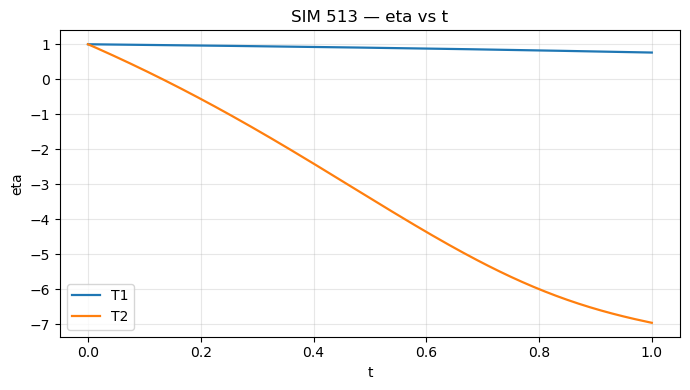

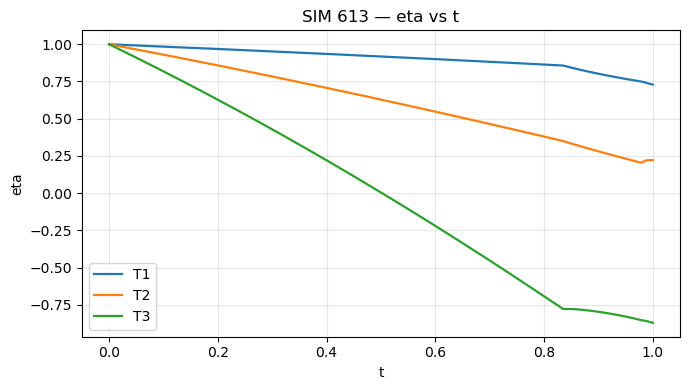

In [7]:
sim=613
T_nums = [1,2,3,4,5]

for sim in [513, 613]:
    # T_nums = [1]
    fig, ax = plt.subplots(figsize=(7, 4))



    for T_num in T_nums:
        pkl_path = ROOT / "I001_Results" / f"DATA_PICK_{sim:03d}_T2_{T_num:03d}.pkl"

        if not pkl_path.exists():
            print(f"File {pkl_path} does not exist")
            continue

        with pkl_path.open("rb") as f:
            data = pickle.load(f)

        print(data.keys())
        data['eta']


        t = np.array(data["t"], dtype=float)
        eta = np.array(data["eta"], dtype=float)

        ax.plot(t, eta, lw=1.6, label=f"T{T_num}")

    ax.set_xlabel("t")
    ax.set_ylabel("eta")
    ax.set_title(f"SIM {sim:03d} — eta vs t")
    ax.grid(True, alpha=0.3, which="both")
    ax.legend()
    plt.tight_layout()



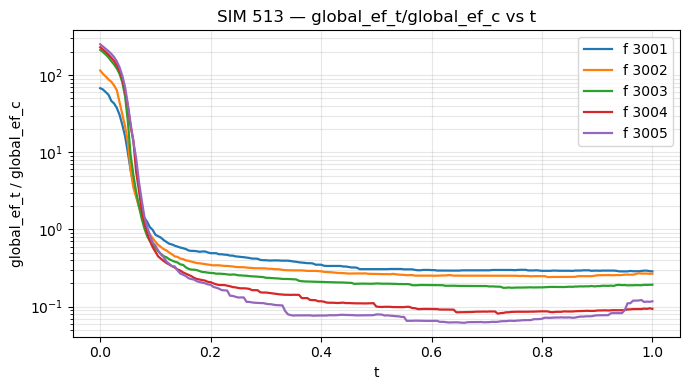

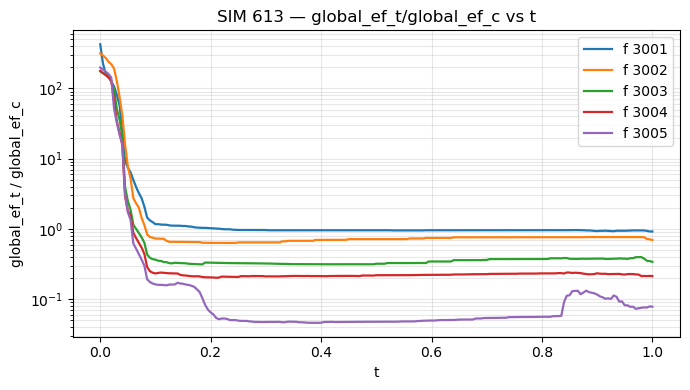

In [6]:
sim=613

H_nums = [3001, 3002, 3003, 3004, 3005]
for sim in [513, 613]:

    fig, ax = plt.subplots(figsize=(7, 4))



    for H_num in H_nums:
        pkl_path = ROOT / "I001_Results" / f"DATA_PICK_{sim:03d}_H3_BFS_{H_num}.pkl"

        if not pkl_path.exists():
            print(f"File {pkl_path} does not exist")
            continue

        with pkl_path.open("rb") as f:
            data = pickle.load(f)

        t = np.array(data["t"], dtype=float)
        ef_t = np.array(data["global_ef_t"], dtype=float)
        ef_c = np.array(data["global_ef_c"], dtype=float)

        ratio = np.divide(
            ef_t,
            ef_c,
            out=np.full_like(ef_t, np.nan, dtype=float),
            where=ef_c != 0,
        )

        ax.plot(t, ratio, lw=1.6, label=f"f {H_num}")

    ax.set_xlabel("t")
    ax.set_ylabel("global_ef_t / global_ef_c")
    ax.set_title(f"SIM {sim:03d} — global_ef_t/global_ef_c vs t")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3, which="both")
    ax.legend()
    plt.tight_layout()
    plt.show()


File /Disk_F/FOAM_V03/I001_Results/DATA_PICK_513_I3_BFS_3004.pkl does not exist
File /Disk_F/FOAM_V03/I001_Results/DATA_PICK_513_I3_BFS_3005.pkl does not exist


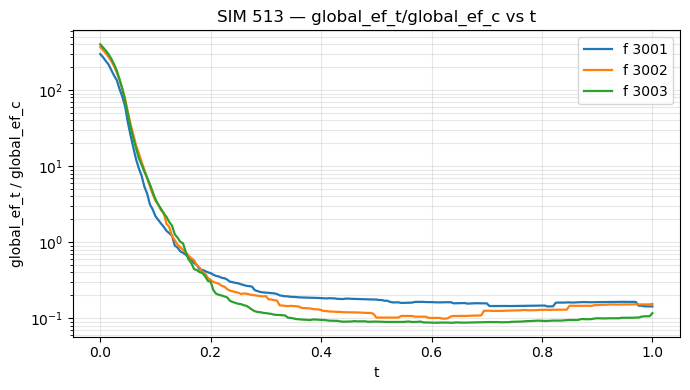

File /Disk_F/FOAM_V03/I001_Results/DATA_PICK_613_I3_BFS_3003.pkl does not exist
File /Disk_F/FOAM_V03/I001_Results/DATA_PICK_613_I3_BFS_3004.pkl does not exist
File /Disk_F/FOAM_V03/I001_Results/DATA_PICK_613_I3_BFS_3005.pkl does not exist


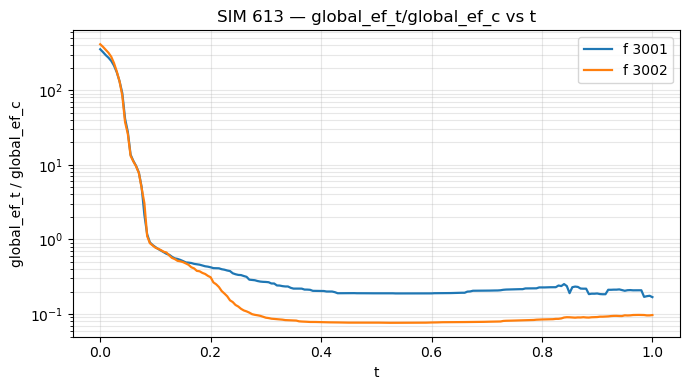

In [ ]:

H_nums = [3001, 3002, 3003, 3004, 3005]
for sim in [513, 613]:

    fig, ax = plt.subplots(figsize=(7, 4))



    for H_num in H_nums:
        pkl_path = ROOT / "I001_Results" / f"DATA_PICK_{sim:03d}_I3_BFS_{H_num}.pkl"

        if not pkl_path.exists():
            print(f"File {pkl_path} does not exist")
            continue

        with pkl_path.open("rb") as f:
            data = pickle.load(f)

        t = np.array(data["t"], dtype=float)
        ef_t = np.array(data["global_ef_t"], dtype=float)
        ef_c = np.array(data["global_ef_c"], dtype=float)

        ratio = np.divide(
            ef_t,
            ef_c,
            out=np.full_like(ef_t, np.nan, dtype=float),
            where=ef_c != 0,
        )

        ax.plot(t, ratio, lw=1.6, label=f"f {H_num}")

    ax.set_xlabel("t")
    ax.set_ylabel("global_ef_t / global_ef_c")
    ax.set_title(f"SIM {sim:03d} — global_ef_t/global_ef_c vs t")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3, which="both")
    ax.legend()
    plt.tight_layout()
    plt.show()


File /Disk_F/FOAM_V03/I001_Results/DATA_PICK_513_I3_BFS_3004.pkl does not exist
File /Disk_F/FOAM_V03/I001_Results/DATA_PICK_513_I3_BFS_3005.pkl does not exist


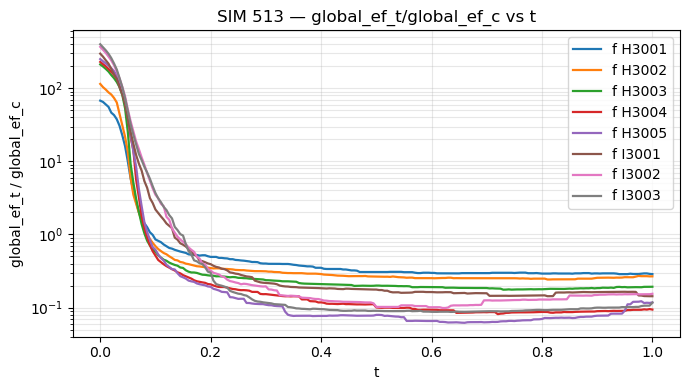

File /Disk_F/FOAM_V03/I001_Results/DATA_PICK_613_I3_BFS_3003.pkl does not exist
File /Disk_F/FOAM_V03/I001_Results/DATA_PICK_613_I3_BFS_3004.pkl does not exist
File /Disk_F/FOAM_V03/I001_Results/DATA_PICK_613_I3_BFS_3005.pkl does not exist


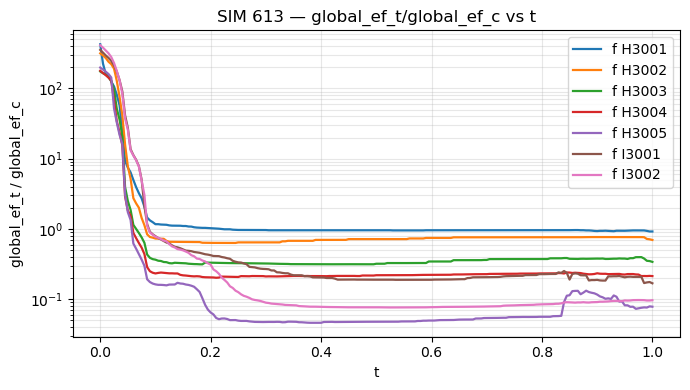

In [11]:
H_nums = [3001, 3002, 3003, 3004, 3005]
I_nums = [3001, 3002, 3003, 3004, 3005]


for sim in [513, 613]:

    fig, ax = plt.subplots(figsize=(7, 4))



    for H_num in H_nums:
        pkl_path = ROOT / "I001_Results" / f"DATA_PICK_{sim:03d}_H3_BFS_{H_num}.pkl"

        if not pkl_path.exists():
            print(f"File {pkl_path} does not exist")
            continue

        with pkl_path.open("rb") as f:
            data = pickle.load(f)

        t = np.array(data["t"], dtype=float)
        ef_t = np.array(data["global_ef_t"], dtype=float)
        ef_c = np.array(data["global_ef_c"], dtype=float)

        ratio = np.divide(
            ef_t,
            ef_c,
            out=np.full_like(ef_t, np.nan, dtype=float),
            where=ef_c != 0,
        )

        ax.plot(t, ratio, lw=1.6, label=f"f H{H_num}")


    for I_num in I_nums:
        pkl_path = ROOT / "I001_Results" / f"DATA_PICK_{sim:03d}_I3_BFS_{I_num}.pkl"

        if not pkl_path.exists():
            print(f"File {pkl_path} does not exist")
            continue

        with pkl_path.open("rb") as f:
            data = pickle.load(f)

        t = np.array(data["t"], dtype=float)
        ef_t = np.array(data["global_ef_t"], dtype=float)
        ef_c = np.array(data["global_ef_c"], dtype=float)

        ratio = np.divide(
            ef_t,
            ef_c,
            out=np.full_like(ef_t, np.nan, dtype=float),
            where=ef_c != 0,
        )

        ax.plot(t, ratio, lw=1.6, label=f"f I{I_num}")


    ax.set_xlabel("t")
    ax.set_ylabel("global_ef_t / global_ef_c")
    ax.set_title(f"SIM {sim:03d} — global_ef_t/global_ef_c vs t")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3, which="both")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [4]:
# ── Helper functions ──────────────────────────────────────────────────────────
import re as _re

def _sort_key(label):
    """Numeric sort key: extracts node count or stab factor from a label string."""
    m = _re.match(r"(\d+)\s+nodes", str(label))
    if m:
        return float(m.group(1))
    m = _re.search(r"stab=([\d.e+\-]+)", str(label))
    if m:
        return float(m.group(1))
    return float("inf")

def load_pkl_A(sim):
    pkl_path = ROOT / "I001_Results" / f"DATA_PICK_{sim:03d}_A.pkl"
    with pkl_path.open("rb") as f:
        return pickle.load(f)

def get_t(data):
    return np.array(data["t"])

def get_rf(data):
    values = data["RF2"]["PERN-9999997"]
    if isinstance(values, dict):
        values = values["9999997"]
    return np.array([-v for v in values])

def get_u2(data):
    values = data["U2"]["PERN-9999997"]
    if isinstance(values, dict):
        values = values["9999997"]
    return np.array([-v for v in values])

def get_allie(data):
    return np.array(data["ALLIE"]["ASSEMBLY"])

def get_allsd_allie_ratio(data):
    allsd = np.array(data["ALLSD"]["ASSEMBLY"], dtype=float)
    allie = np.array(data["ALLIE"]["ASSEMBLY"], dtype=float)
    return np.divide(
        allsd,
        allie,
        out=np.full_like(allsd, np.nan, dtype=float),
        where=allie != 0,
    )

def common_final_time(data_list):
    """Minimum final time across all simulations (ensures all reached this point)."""
    return min(get_t(d)[-1] for d in data_list)

def value_at_time(data, field_fn, t_target):
    t = get_t(data)
    idx = np.searchsorted(t, t_target, side="right") - 1
    idx = max(0, min(idx, len(t) - 1))
    return field_fn(data)[idx]

def transpose_groups(mesh_stab_dict):
    """
    {mesh_label: {stab_label: sim}} -> {stab_label: {mesh_label: sim}}
    """
    transposed = {}
    for mesh_label, stab_dict in mesh_stab_dict.items():
        for stab_label, sim in stab_dict.items():
            transposed.setdefault(stab_label, {})[mesh_label] = sim
    return transposed

def convergence_plots(groups, all_data, field_fn, x_fn, field_label, x_label, series_name):
    """
    Produces three phases across all outer groups (sorted smallest → largest):
      Phase 1 – all full-curve plots (one per outer group)
      Phase 2 – convergence + error side-by-side subplots (one per outer group)
                Left : final value vs parameter
                Right: relative error (%) in log-log scale

    Within every plot, inner labels are also sorted smallest → largest.

    groups    : {outer_label: {inner_label: sim_num}}
    all_data  : {sim_num: pkl_data}
    field_fn  : data -> np.array   (y-axis values)
    x_fn      : data -> np.array   (x-axis values)
    """
    sorted_outer = sorted(groups.keys(), key=_sort_key)
    use_log_x = any(_sort_key(lbl) != float("inf") for lbl in groups.keys())

    # Pre-compute per-group data (sort inner labels, skip missing sims)
    prepared = {}
    for outer_label in sorted_outer:
        inner_dict = groups[outer_label]
        available_sorted = {
            lbl: inner_dict[lbl]
            for lbl in sorted(inner_dict.keys(), key=_sort_key)
            if inner_dict[lbl] in all_data
        }
        if not available_sorted:
            print(f"No data available for {series_name} — {outer_label}, skipping.")
            continue
        data_list = [all_data[s] for s in available_sorted.values()]
        t_common = common_final_time(data_list)
        final_vals = {
            lbl: value_at_time(all_data[sim], field_fn, t_common)
            for lbl, sim in available_sorted.items()
        }
        prepared[outer_label] = {
            "available": available_sorted,
            "t_common": t_common,
            "final_vals": final_vals,
        }

    valid_outer = [lbl for lbl in sorted_outer if lbl in prepared]

    # ── Phase 1: all full-curve plots ────────────────────────────────────────
    for outer_label in valid_outer:
        entry = prepared[outer_label]
        fig, ax = plt.subplots(figsize=(6.5, 4.2))
        for lbl, sim in entry["available"].items():
            d = all_data[sim]
            ax.plot(x_fn(d), field_fn(d), label=f"{lbl} (SIM {sim:03d})")
        ax.set_xlabel(x_label)
        ax.set_ylabel(field_label)
        ax.set_title(f"{series_name} — {outer_label}")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

    # ── Phase 2: convergence + error side-by-side ─────────────────────────────
    for outer_label in valid_outer:
        entry = prepared[outer_label]
        inner_labels = list(entry["available"].keys())
        values = [entry["final_vals"][lbl] for lbl in inner_labels]

        fig, (ax_conv, ax_err) = plt.subplots(1, 2, figsize=(13, 4.2))
        numeric_inner = [_sort_key(lbl) for lbl in inner_labels]

        # Left – convergence (final value vs parameter)
        ax_conv.plot(numeric_inner, values, marker="o")
        ax_conv.set_xlabel("Parameter")
        ax_conv.set_ylabel(f"Final {field_label}  (t = {entry['t_common']:.4f})")
        ax_conv.set_title(f"{series_name} — {outer_label}\nfinal {field_label}")
        if use_log_x:
            ax_conv.set_xscale("log")
        else:
            ax_conv.set_xticks(range(len(inner_labels)))
            ax_conv.set_xticklabels(inner_labels, rotation=15, ha="right")
        ax_conv.grid(True, alpha=0.3)

        # Right – error in log-log scale
        if len(values) > 1:
            errors = [
                abs((values[i] - values[i - 1]) / values[i - 1]) * 100
                if values[i - 1] != 0 else float("nan")
                for i in range(1, len(values))
            ]
            err_labels = [f"{inner_labels[i - 1]} → {inner_labels[i]}"
                          for i in range(1, len(inner_labels))]
            ax_err.plot(range(len(errors)), errors, marker="o", color="tab:red")
            ax_err.set_xticks(range(len(err_labels)))
            ax_err.set_xticklabels(err_labels, rotation=15, ha="right")
            ax_err.set_xlabel("Transition")
            ax_err.set_ylabel("Error (%)")
            ax_err.set_title(f"{series_name} — {outer_label}\nerror in final {field_label}")
            ax_err.grid(True, which="both", alpha=0.3)
        else:
            ax_err.set_visible(False)

        plt.tight_layout()
        plt.show()


In [3]:
# ── Load all PKL_A files ──────────────────────────────────────────────────────
all_sims = {
    sim
    for mesh_dict in SERIES.values()
    for stab_dict in mesh_dict.values()
    for sim in stab_dict.values()
}

all_data = {}
for sim in sorted(all_sims):
    try:
        all_data[sim] = load_pkl_A(sim)
        t_final = get_t(all_data[sim])[-1]
        print(f"SIM {sim:03d}: loaded OK  (t_final = {t_final:.4f})")
    except FileNotFoundError:
        print(f"SIM {sim:03d}: NOT FOUND — will be skipped in all plots")


SIM 500: loaded OK  (t_final = 1.0000)
SIM 501: loaded OK  (t_final = 1.0000)
SIM 502: loaded OK  (t_final = 1.0000)
SIM 503: loaded OK  (t_final = 1.0000)
SIM 504: loaded OK  (t_final = 1.0000)
SIM 600: loaded OK  (t_final = 1.0000)
SIM 601: loaded OK  (t_final = 1.0000)
SIM 602: loaded OK  (t_final = 1.0000)
SIM 603: loaded OK  (t_final = 1.0000)
SIM 604: loaded OK  (t_final = 1.0000)


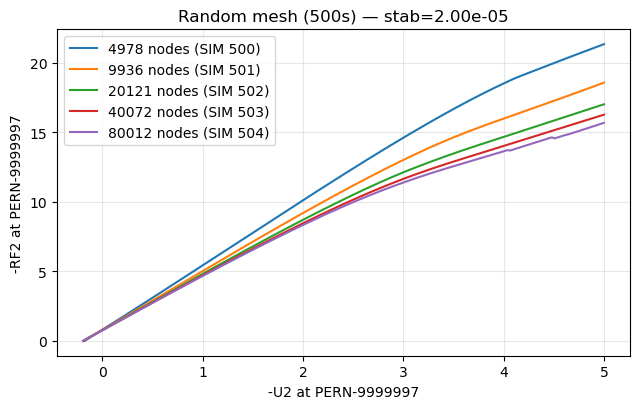

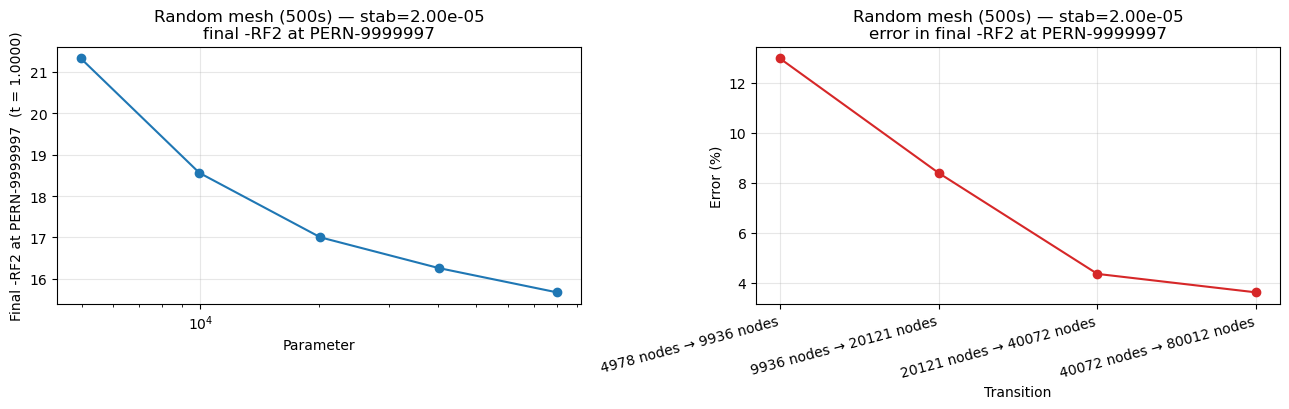

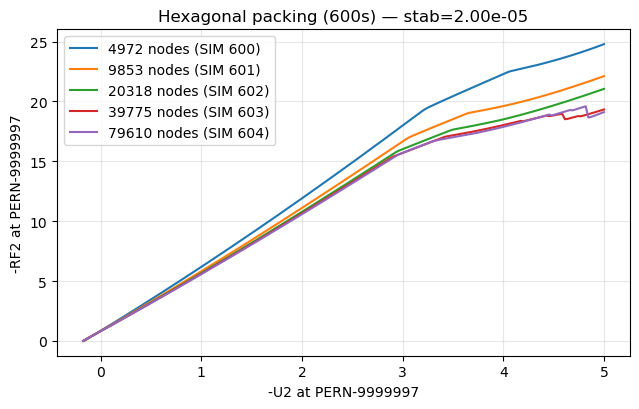

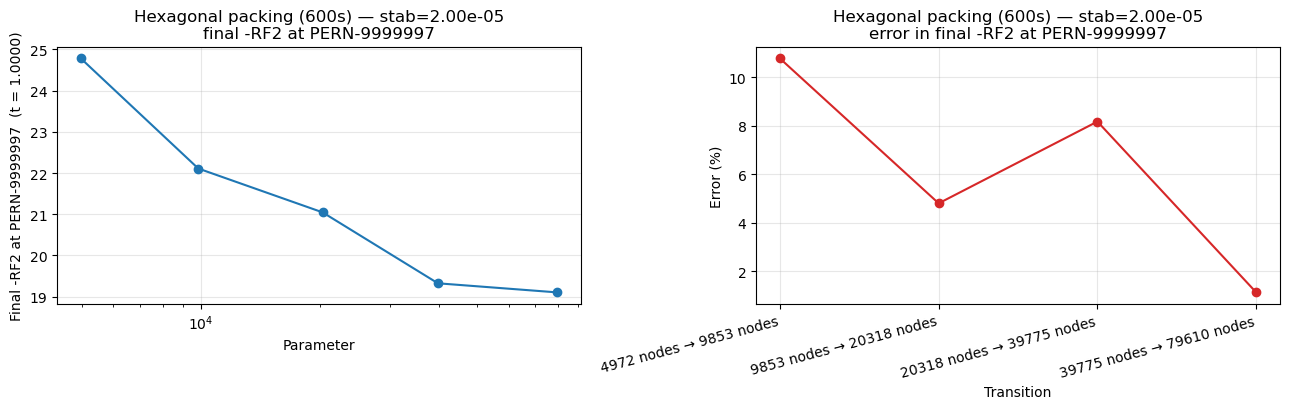

In [4]:
# ── RF — grouped by stabilization factor ─────────────────────────────────────
# One set of 3 plots per (series × stab factor): curves / final values / errors
# Inner parameter varying across curves: mesh size

for series_name, mesh_dict in SERIES.items():
    stab_groups = transpose_groups(mesh_dict)
    convergence_plots(
        groups=stab_groups,
        all_data=all_data,
        field_fn=get_rf,
        x_fn=get_u2,
        field_label="-RF2 at PERN-9999997",
        x_label="-U2 at PERN-9999997",
        series_name=series_name,
    )


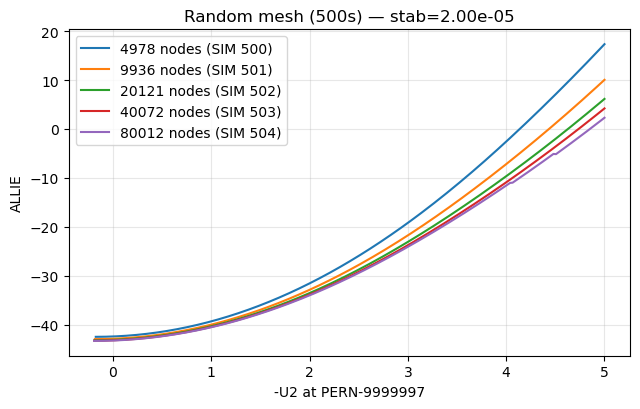

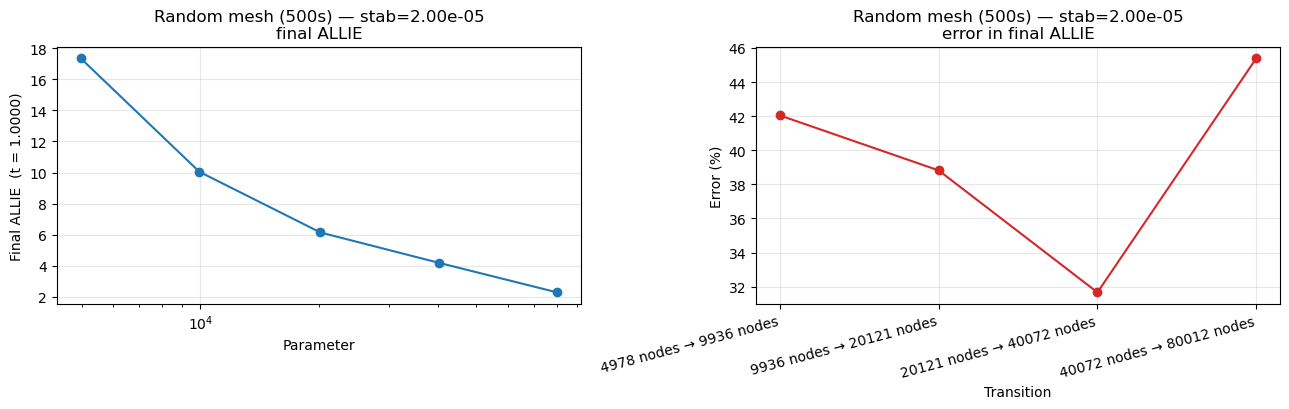

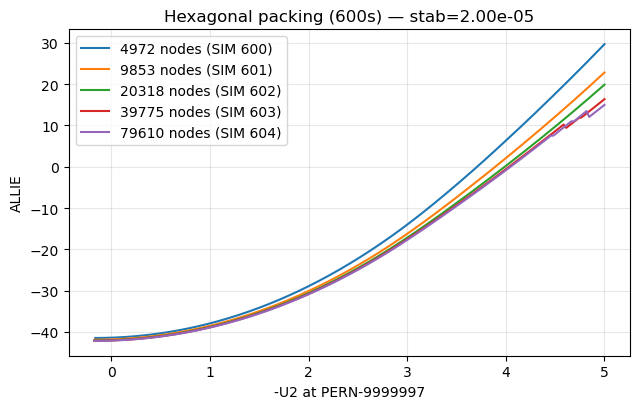

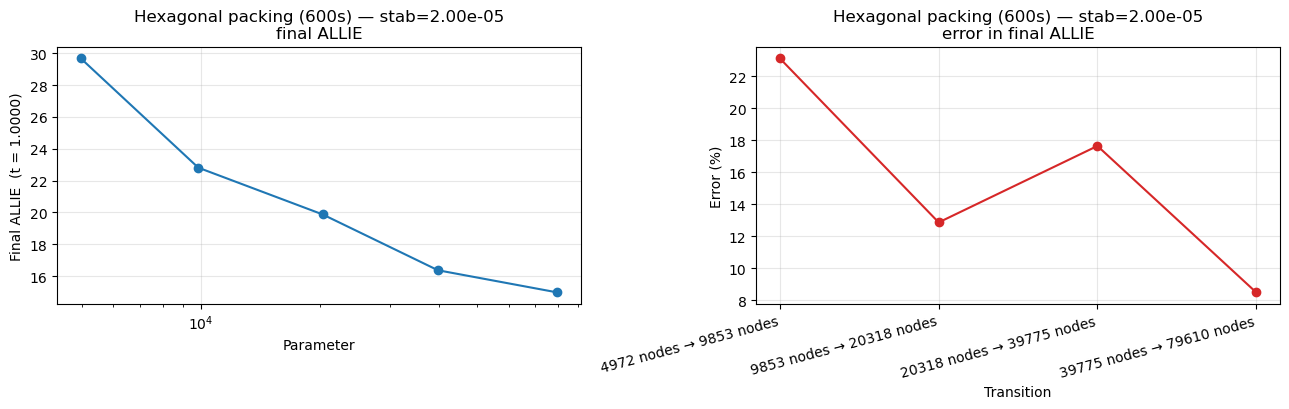

In [5]:
# ── ALLIE — grouped by stabilization factor ───────────────────────────────────
# One set of 3 plots per (series × stab factor): curves / final values / errors
# Inner parameter varying across curves: mesh size

for series_name, mesh_dict in SERIES.items():
    stab_groups = transpose_groups(mesh_dict)
    convergence_plots(
        groups=stab_groups,
        all_data=all_data,
        field_fn=get_allie,
        x_fn=get_u2,
        field_label="ALLIE",
        x_label="-U2 at PERN-9999997",
        series_name=series_name,
    )


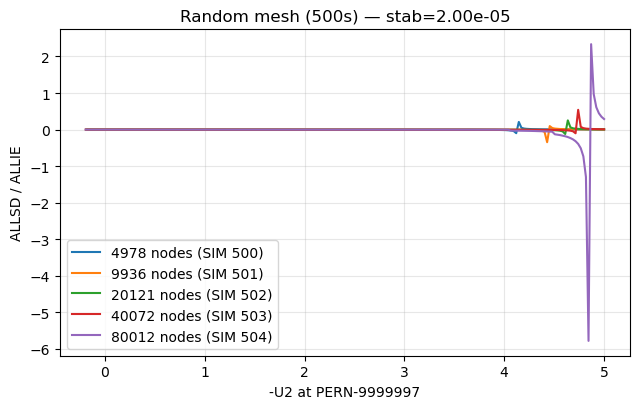

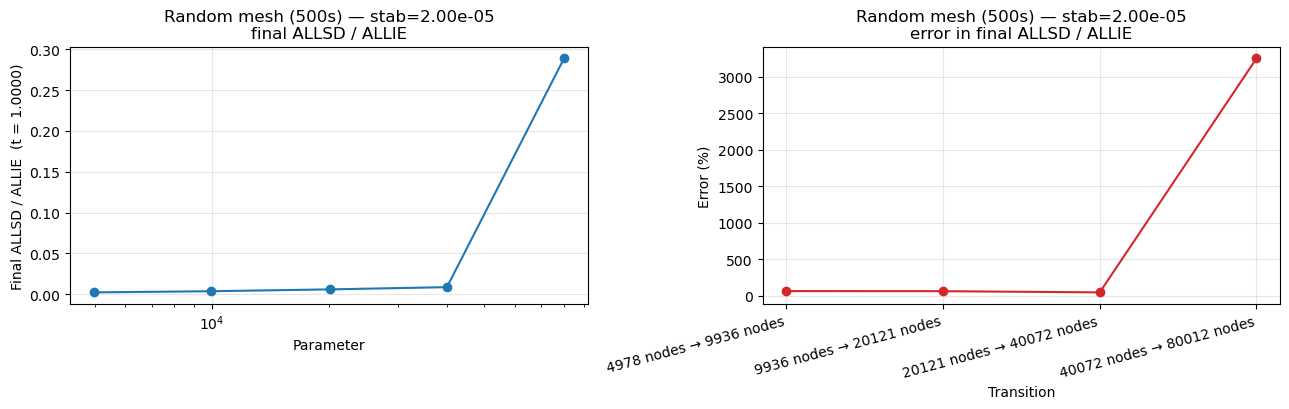

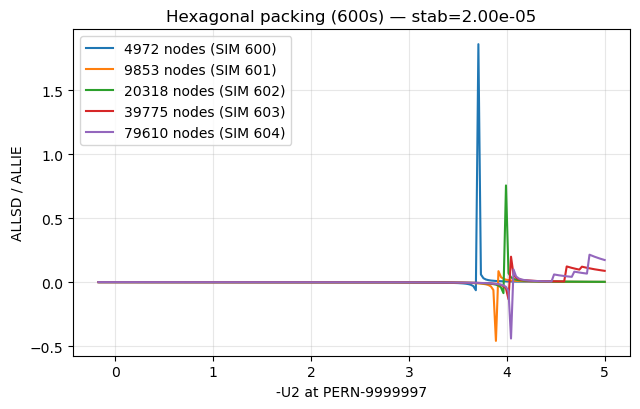

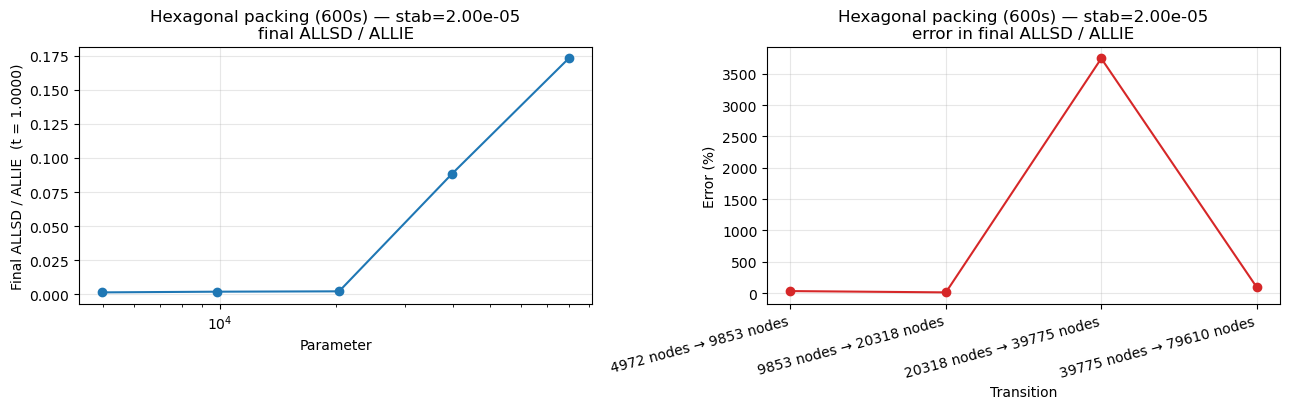

In [6]:
# ── ALLSD / ALLIE ratio — grouped by stabilization factor ─────────────────────
# One set of 3 plots per (series × stab factor): curves / final values / errors
# Inner parameter varying across curves: mesh size

for series_name, mesh_dict in SERIES.items():
    stab_groups = transpose_groups(mesh_dict)
    convergence_plots(
        groups=stab_groups,
        all_data=all_data,
        field_fn=get_allsd_allie_ratio,
        x_fn=get_u2,
        field_label="ALLSD / ALLIE",
        x_label="-U2 at PERN-9999997",
        series_name=series_name,
    )


Random mesh (500s)  (ref SIM 500):
  P1: (4.152, 18.734)
  P2: (5.091, 5.679)
  P3: (19.701, 18.221)
  P4: (7.298, 12.878)
Hexagonal packing (600s)  (ref SIM 600):
  P1: (4.514, 10.697)
  P2: (7.588, 0.468)
  P3: (7.998, 3.346)
  P4: (3.552, 2.163)


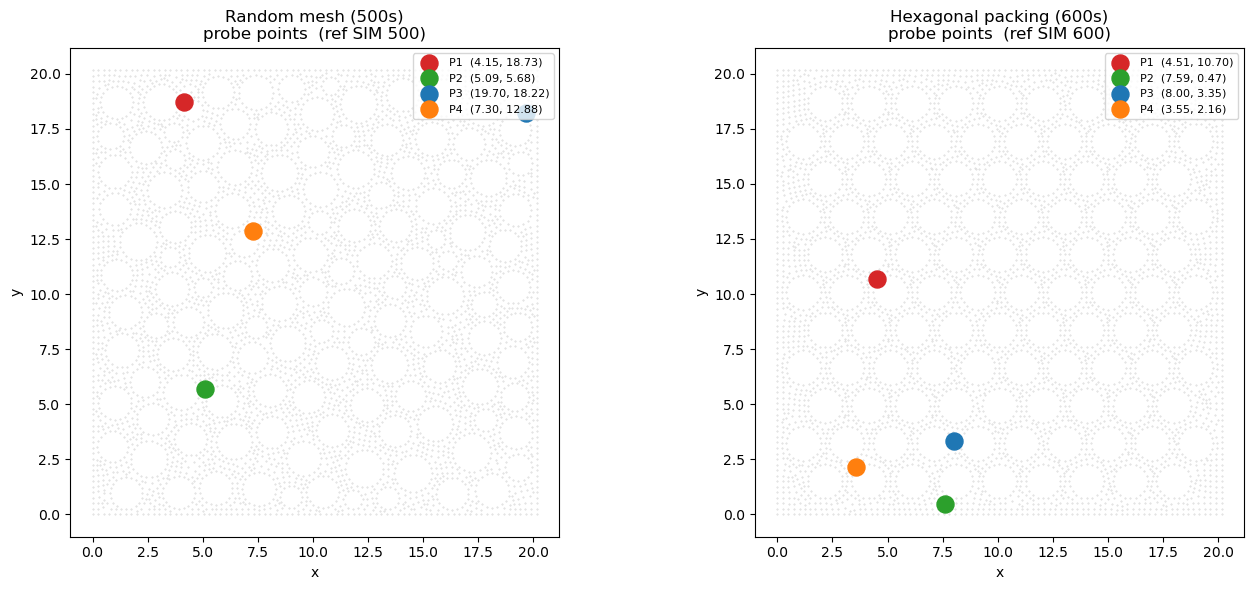

In [7]:
# ── S11 at probe points — setup ───────────────────────────────────────────────
# Pick 4 probe points per series. Each point is the centroid of a randomly
# chosen element, which guarantees:
#   (a) the point is inside solid material (never inside a hole), and
#   (b) it cannot coincide with any mesh node.
# A fixed RNG seed makes the choice reproducible.

import sys
sys.path.insert(0, str(ROOT))
from A001_functions.fem_stress_interpolation import (
    interpolate_stress,
    _get_stress_at_integration_points,
    _interpolate_at_natural_coords,
)

_RNG_SEED = 42
_N_PROBES = 4
_MIN_SEP  = 1.0   # min distance between probe points (mesh coord units)


def _pick_probe_points(c2, n=_N_PROBES, seed=_RNG_SEED, min_sep=_MIN_SEP):
    """Return n well-separated element-centroid (x, y) tuples."""
    rng       = np.random.default_rng(seed)
    node_dict = c2['nodes_time'][0]
    elem_dict = c2['elements']
    keys      = sorted(elem_dict.keys(), key=int)
    draw_idx  = rng.choice(len(keys), size=min(len(keys), n * 80), replace=False)
    pts = []
    for idx in draw_idx:
        ek    = keys[idx]
        verts = np.array([node_dict[str(nd)] for nd in elem_dict[ek]])
        cx, cy = verts.mean(axis=0)
        if all(np.hypot(cx - px, cy - py) > min_sep for px, py in pts):
            pts.append((float(cx), float(cy)))
        if len(pts) == n:
            break
    return pts


# ── Reference simulation per series (first available C2 pickle) ──────────────
def _find_reference_sim(series_groups):
    """Return the first SIM in the series that has a C2 pickle on disk."""
    candidates = sorted({sim for stab_dict in series_groups.values() for sim in stab_dict.values()})
    for sim in candidates:
        pkl_path = ROOT / "I001_Results" / f"DATA_PICK_{sim:03d}_C2.pkl"
        if pkl_path.exists():
            return sim
    return None

_REF_SIM = {}
for sname, gd in SERIES.items():
    _ref_sim = _find_reference_sim(gd)
    if _ref_sim is None:
        print(f"{sname}: no C2 pickle found — probe points skipped")
        continue
    _REF_SIM[sname] = _ref_sim

if not _REF_SIM:
    print("No reference simulations available — skipping probe-point setup.")


PROBE_POINTS = {}      # series_name -> [(x0,y0), (x1,y1), ...]
_ref_c2_store = {}

for _sname, _rsim in _REF_SIM.items():
    _pkl = ROOT / "I001_Results" / f"DATA_PICK_{_rsim:03d}_C2.pkl"
    with _pkl.open("rb") as _fh:
        _rc2 = pickle.load(_fh)
    _ref_c2_store[_sname] = _rc2
    PROBE_POINTS[_sname]  = _pick_probe_points(_rc2)
    print(f"{_sname}  (ref SIM {_rsim:03d}):")
    for _i, (_px, _py) in enumerate(PROBE_POINTS[_sname]):
        print(f"  P{_i + 1}: ({_px:.3f}, {_py:.3f})")


# ── Visualise probe points on the reference mesh ─────────────────────────────
_PT_COLORS = ["tab:red", "tab:green", "tab:blue", "tab:orange"]
_n_series  = len(PROBE_POINTS)

if _n_series > 0:
    _fig, _axes = plt.subplots(1, _n_series, figsize=(7 * _n_series, 6),
                                squeeze=False)
    for _ax, (_sname, _rc2) in zip(_axes[0], _ref_c2_store.items()):
        _xy = np.array(list(_rc2['nodes_time'][0].values()))
        _ax.scatter(_xy[:, 0], _xy[:, 1], s=0.15, c="lightgray",
                    zorder=1, rasterized=True)
        for _i, (_px, _py) in enumerate(PROBE_POINTS[_sname]):
            _ax.scatter(_px, _py, s=150, c=_PT_COLORS[_i], zorder=3,
                        label=f"P{_i + 1}  ({_px:.2f}, {_py:.2f})")
        _ax.set_title(f"{_sname}\nprobe points  (ref SIM {_REF_SIM[_sname]:03d})")
        _ax.set_xlabel("x"); _ax.set_ylabel("y")
        _ax.legend(fontsize=8, loc="upper right")
        _ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()
else:
    print("No probe points to visualize.")


In [8]:
# ── S11 + deformed positions — precompute time series ─────────────────────────
# For every simulation in all_data:
#   1. Load DATA_B + DATA_C2.
#   2. Locate each probe point's containing element once (reference config t=0).
#   3. Cache (element_key, xi, eta, shape-functions N).
#   4. Sweep all time steps:
#        - deformed position  = N @ deformed_nodal_coords
#        - S11 from integration-point lookup + interpolation
# Results stored in all_data[sim]:
#   'S11_pt{i}'  : np.array(n_t)   — S11 time series
#   'X_pt{i}'    : np.array(n_t)   — deformed x position
#   'Y_pt{i}'    : np.array(n_t)   — deformed y position

import sys
sys.path.insert(0, str(ROOT))

from A001_functions.fem_stress_interpolation import (
    interpolate_stress,
    _get_stress_at_integration_points,
    _interpolate_at_natural_coords,
    _shape_functions,
    _shape_functions_tri,
)


def _compute_s11_and_pos(sim, probe_pts):
    """
    Returns list of (s11_arr, x_arr, y_arr) tuples (one per probe point),
    or None if DATA_B / DATA_C2 files are missing.
    """
    path_b  = ROOT / "I001_Results" / f"DATA_PICK_{sim:03d}_B.pkl"
    path_c2 = ROOT / "I001_Results" / f"DATA_PICK_{sim:03d}_C2.pkl"
    if not (path_b.exists() and path_c2.exists()):
        return None

    with path_b.open("rb")  as fh: B  = pickle.load(fh)
    with path_c2.open("rb") as fh: C2 = pickle.load(fh)

    n_t = len(B['t'])
    results = []

    for px, py in probe_pts:
        # locate element at reference configuration (t=0, ti_key='1')
        info     = interpolate_stress(C2, B, px, py, ti_key='1')
        ek       = info['element_idx']
        xi       = info['xi']
        eta      = info['eta']
        node_ids = [str(n) for n in C2['elements'][ek]]
        n_en     = len(node_ids)

        # shape-function weights are fixed across all time steps
        N = _shape_functions_tri(xi, eta) if n_en == 3 else _shape_functions(xi, eta)

        s11_t = np.empty(n_t)
        x_t   = np.empty(n_t)
        y_t   = np.empty(n_t)

        for ti_idx in range(n_t):
            nd_pos = np.array([C2['nodes_time'][ti_idx][nid] for nid in node_ids])
            xy     = N @ nd_pos
            x_t[ti_idx], y_t[ti_idx] = float(xy[0]), float(xy[1])

            s11_ip, _, _ = _get_stress_at_integration_points(
                B, ek, str(ti_idx + 1), n_element_nodes=n_en
            )
            s11_t[ti_idx] = (float(s11_ip[0]) if n_en == 3
                             else _interpolate_at_natural_coords(xi, eta, s11_ip))

        results.append((s11_t, x_t, y_t))

    return results


def _series_of_sim(sim_num):
    """Return the SERIES key that contains sim_num, or None."""
    for sname, mesh_dict in SERIES.items():
        for stab_dict in mesh_dict.values():
            if sim_num in stab_dict.values():
                return sname
    return None


def get_s11_pt(pt_idx):
    """field_fn compatible with convergence_plots — returns S11 at probe point pt_idx."""
    _key = f'S11_pt{pt_idx}'
    def _fn(data):
        arr = data.get(_key)
        return arr if arr is not None else np.full(len(get_t(data)), np.nan)
    return _fn


# ── Run for all loaded simulations ────────────────────────────────────────────
for _sim in sorted(all_data.keys()):
    _sname = _series_of_sim(_sim)
    if _sname is None:
        continue
    _pts    = PROBE_POINTS.get(_sname, [])
    _result = _compute_s11_and_pos(_sim, _pts)
    if _result is None:
        print(f"SIM {_sim:03d}: B/C2 not found — skipped")
        continue
    for _i, (_s11, _xarr, _yarr) in enumerate(_result):
        all_data[_sim][f'S11_pt{_i}'] = _s11
        all_data[_sim][f'X_pt{_i}']   = _xarr
        all_data[_sim][f'Y_pt{_i}']   = _yarr
    print(f"SIM {_sim:03d}: S11 + positions computed at {len(_pts)} probe points")


SIM 500: S11 + positions computed at 4 probe points
SIM 501: S11 + positions computed at 4 probe points
SIM 502: S11 + positions computed at 4 probe points
SIM 503: S11 + positions computed at 4 probe points
SIM 504: S11 + positions computed at 4 probe points
SIM 600: S11 + positions computed at 4 probe points
SIM 601: S11 + positions computed at 4 probe points
SIM 602: S11 + positions computed at 4 probe points
SIM 603: S11 + positions computed at 4 probe points
SIM 604: S11 + positions computed at 4 probe points


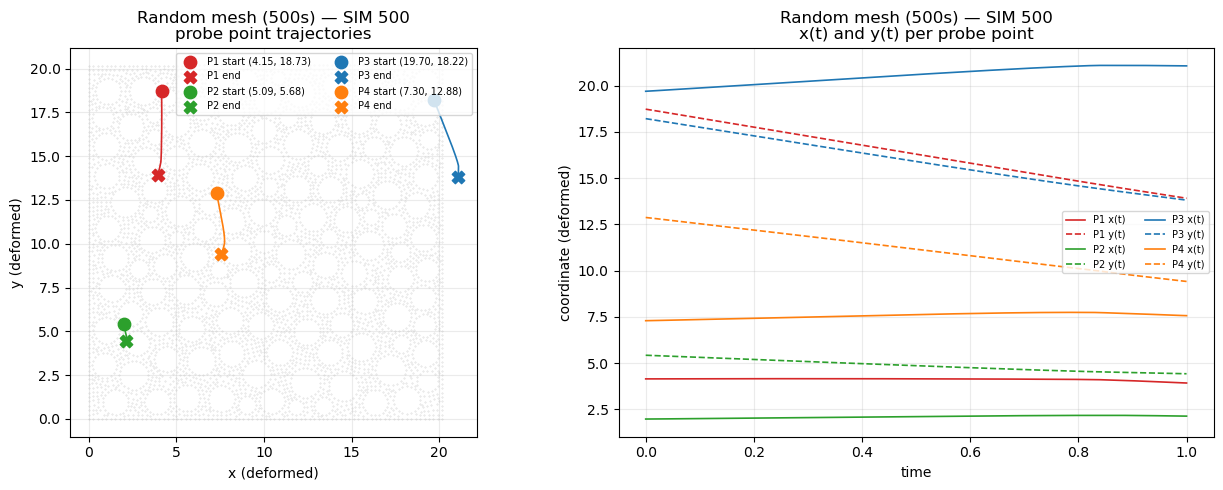

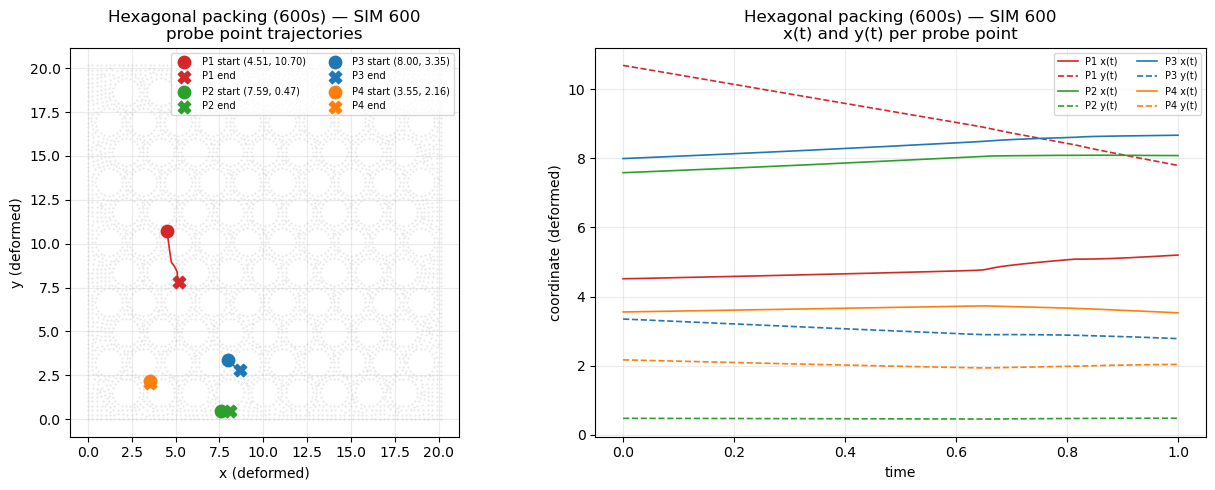

In [9]:
# ── Probe point trajectory — deformed position over time ──────────────────────
# For the reference simulation of each series, shows how each probe point moves
# through space as the specimen is compressed.
#
# Left  subplot : 2-D spatial path (x, y) — circle = start, × = end
# Right subplot : x(t) and y(t) component curves vs time

_PT_COLORS = ["tab:red", "tab:green", "tab:blue", "tab:orange"]

for _sname, _rsim in _REF_SIM.items():
    _d = all_data.get(_rsim)
    if _d is None:
        continue

    _pts  = PROBE_POINTS[_sname]
    _fig, (_ax_xy, _ax_t) = plt.subplots(1, 2, figsize=(13, 5))

    # left: 2-D spatial trajectories
    _xy_mesh = np.array(list(_ref_c2_store[_sname]['nodes_time'][0].values()))
    _ax_xy.scatter(_xy_mesh[:, 0], _xy_mesh[:, 1],
                   s=0.1, c="lightgray", zorder=1, rasterized=True)

    for _i, (_px0, _py0) in enumerate(_pts):
        _xarr = _d[f'X_pt{_i}']
        _yarr = _d[f'Y_pt{_i}']
        _c    = _PT_COLORS[_i]
        _ax_xy.plot(_xarr, _yarr, color=_c, lw=1.2, zorder=2)
        _ax_xy.scatter(_xarr[0],  _yarr[0],  s=80, c=_c, marker="o", zorder=4,
                       label=f"P{_i+1} start ({_px0:.2f}, {_py0:.2f})")
        _ax_xy.scatter(_xarr[-1], _yarr[-1], s=80, c=_c, marker="X", zorder=4,
                       label=f"P{_i+1} end")

    _ax_xy.set_xlabel("x (deformed)")
    _ax_xy.set_ylabel("y (deformed)")
    _ax_xy.set_title(f"{_sname} — SIM {_rsim:03d}\nprobe point trajectories")
    _ax_xy.set_aspect("equal")
    _ax_xy.legend(fontsize=7, ncol=2, loc="upper right")
    _ax_xy.grid(True, alpha=0.25)

    # right: x(t) and y(t) vs time
    _t_arr = get_t(_d)
    for _i in range(len(_pts)):
        _c = _PT_COLORS[_i]
        _ax_t.plot(_t_arr, _d[f'X_pt{_i}'], color=_c, lw=1.2,
                   linestyle="-",  label=f"P{_i+1} x(t)")
        _ax_t.plot(_t_arr, _d[f'Y_pt{_i}'], color=_c, lw=1.2,
                   linestyle="--", label=f"P{_i+1} y(t)")

    _ax_t.set_xlabel("time")
    _ax_t.set_ylabel("coordinate (deformed)")
    _ax_t.set_title(f"{_sname} — SIM {_rsim:03d}\nx(t) and y(t) per probe point")
    _ax_t.legend(fontsize=7, ncol=2, loc="best")
    _ax_t.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


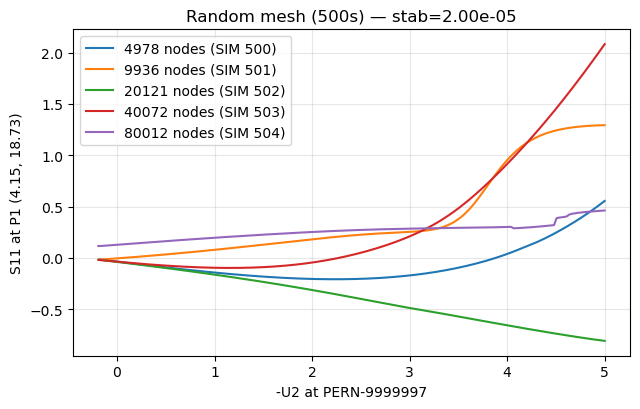

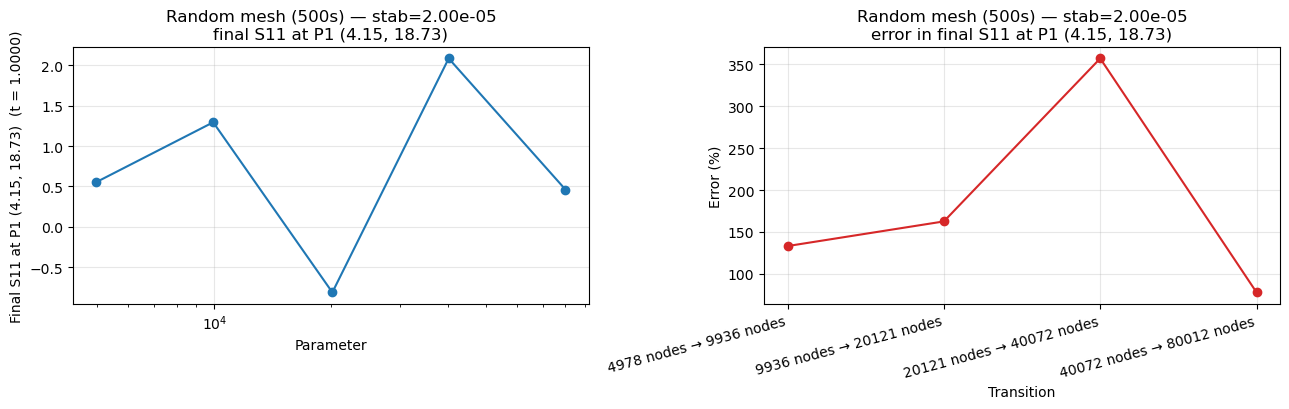

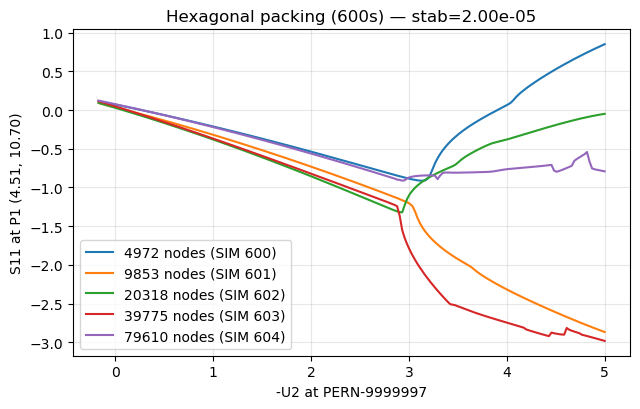

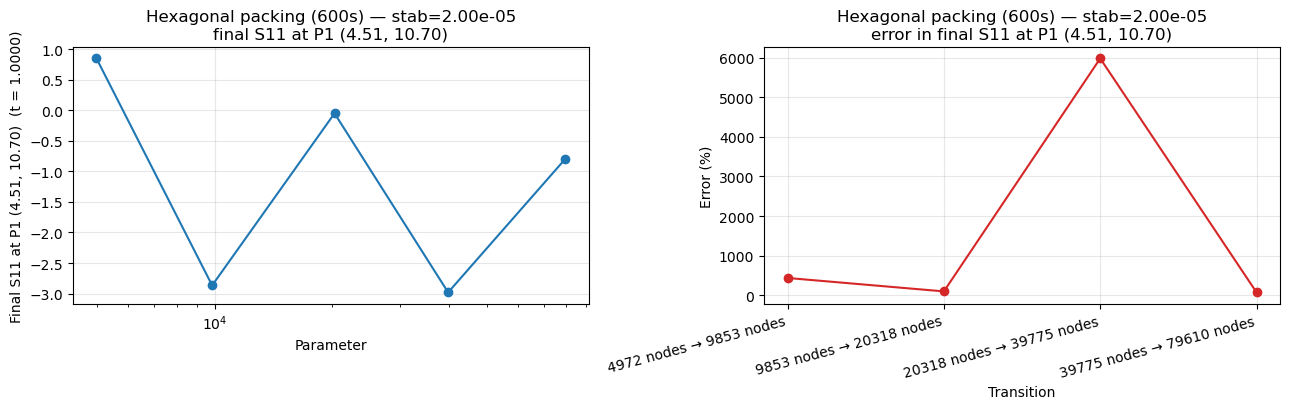

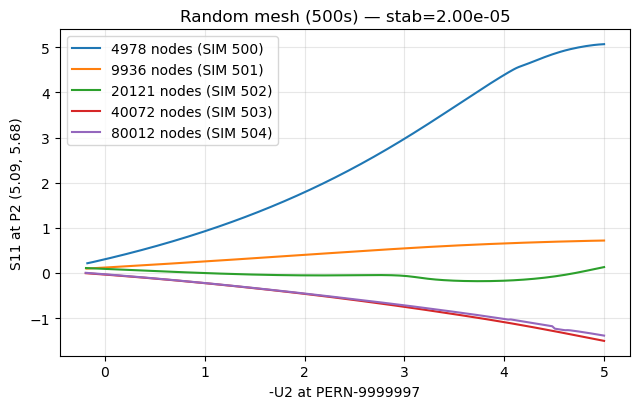

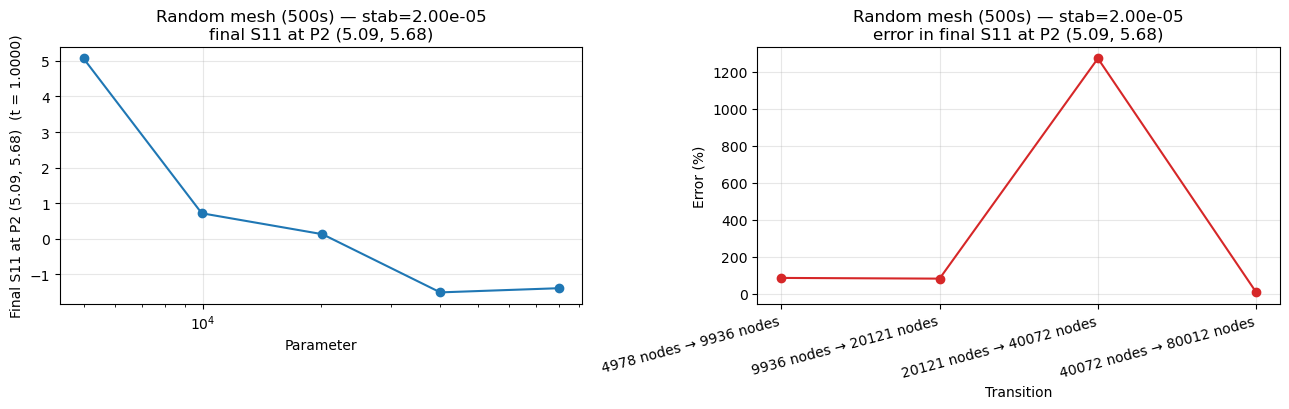

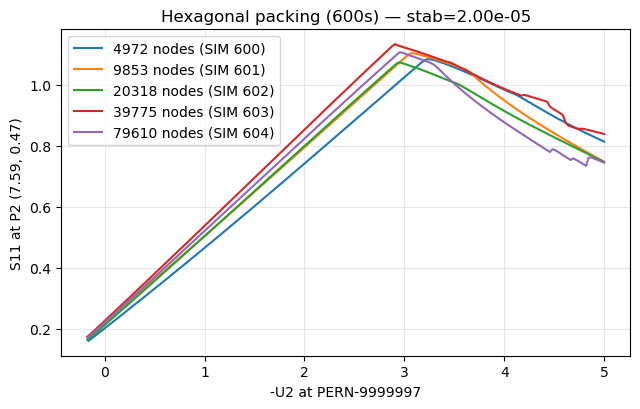

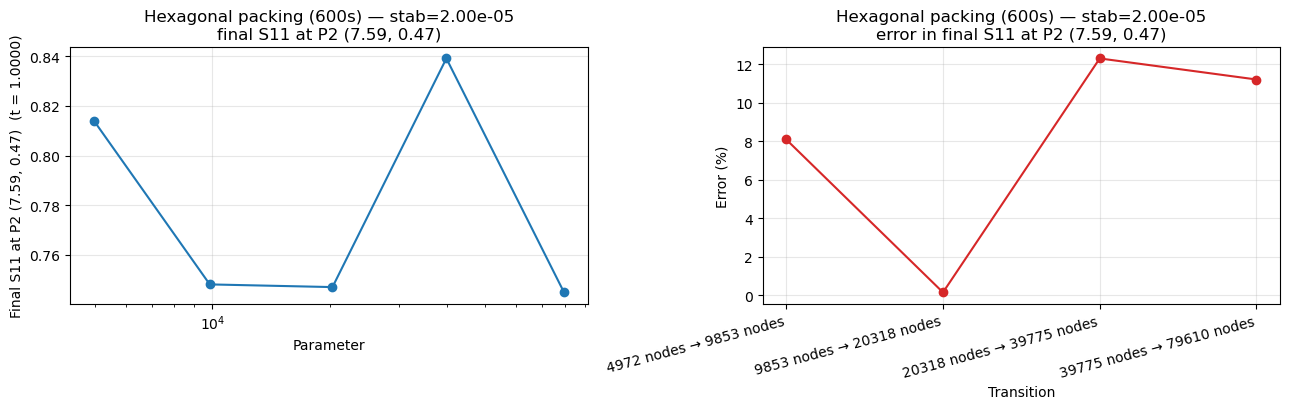

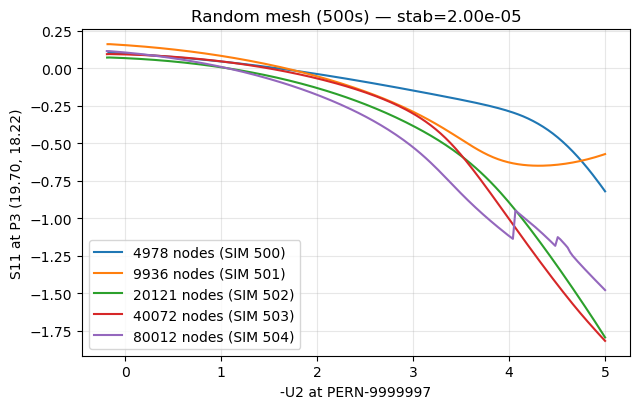

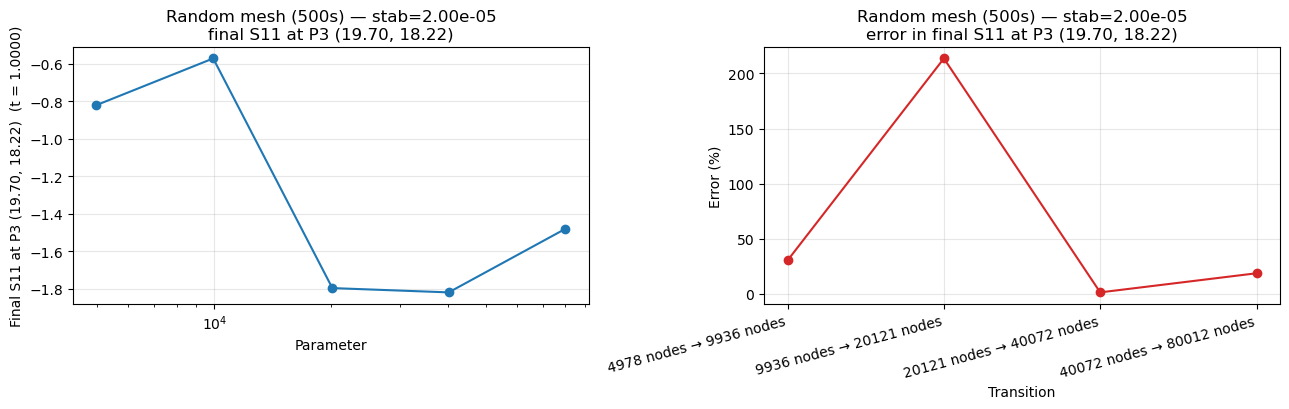

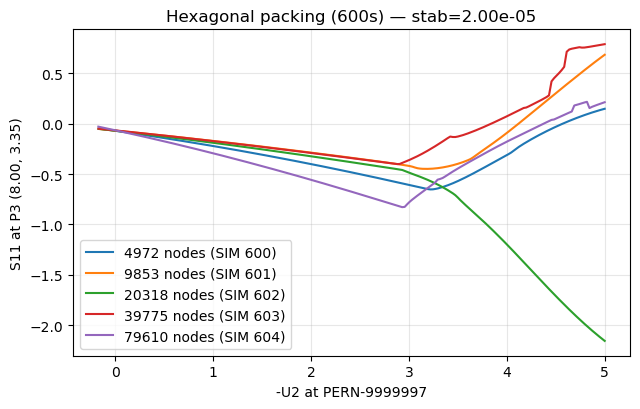

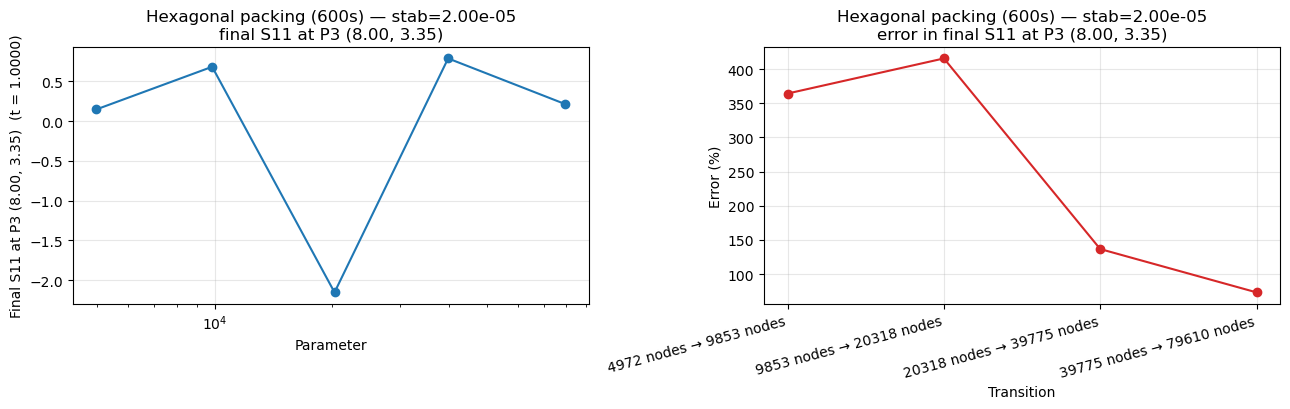

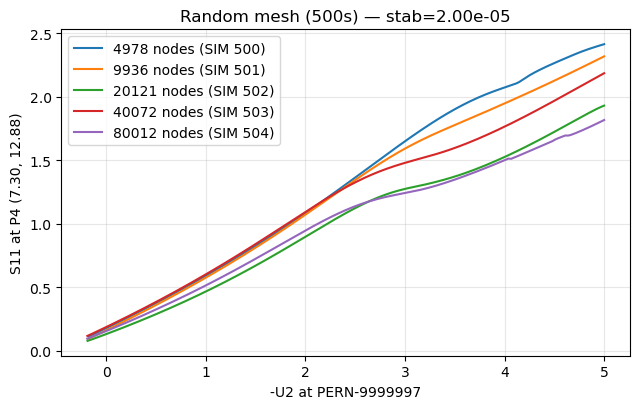

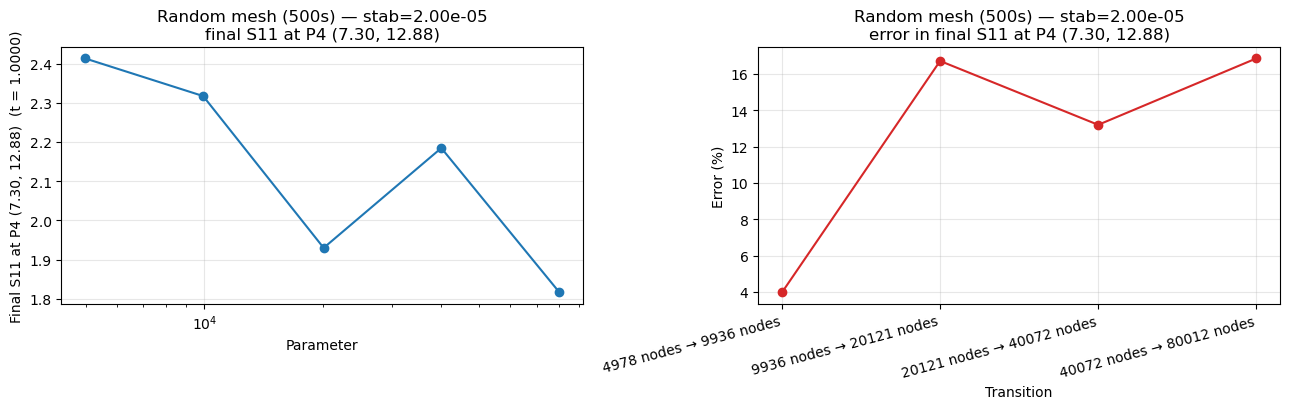

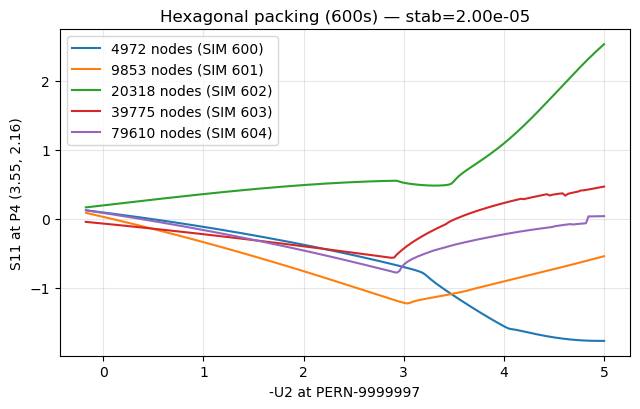

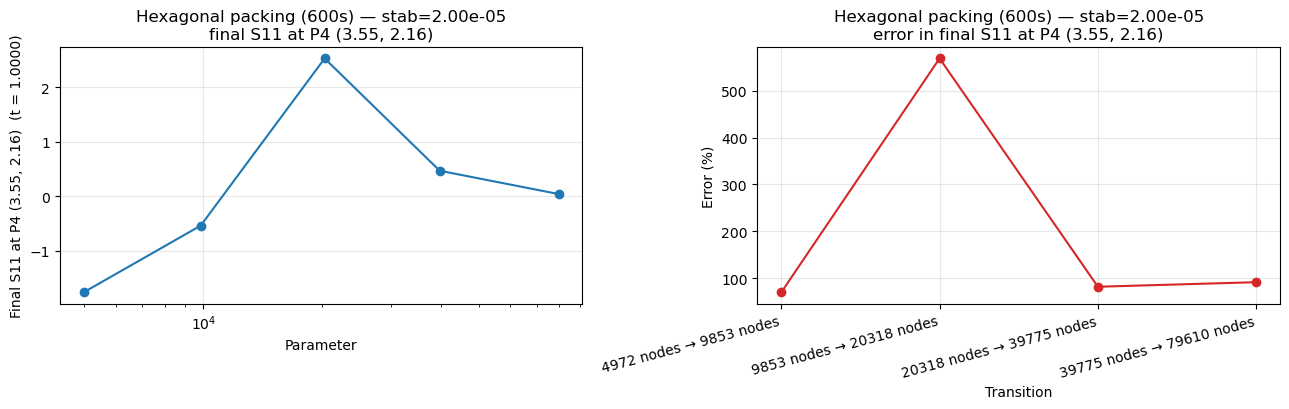

In [10]:
# ── S11 at probe points — convergence grouped by stabilisation factor ─────────
# Same probe points and series; outer variable is the stabilisation factor,
# inner variable (curves within each plot) is the mesh size.

for _pt in range(_N_PROBES):
    _field_fn = get_s11_pt(_pt)
    for _sname, _mesh_dict in SERIES.items():
        _stab_groups = transpose_groups(_mesh_dict)
        _px, _py = PROBE_POINTS[_sname][_pt]
        convergence_plots(
            groups=_stab_groups,
            all_data=all_data,
            field_fn=_field_fn,
            x_fn=get_u2,
            field_label=f"S11 at P{_pt + 1} ({_px:.2f}, {_py:.2f})",
            x_label="-U2 at PERN-9999997",
            series_name=_sname,
        )


In [ ]:
# -- Principal stresses at probe points -- convergence grouped by stabilisation factor
# Uses the same probe points as the S11 analysis. For each probe point it computes:
#   sigma_max, sigma_min = eigenvalues of [[S11, S12], [S12, S22]]
#   theta_max = 0.5 * atan2(2*S12, S11-S22)
#   theta_min = theta_max + pi/2
# Angles are stored in radians and degrees; convergence plots use degrees.



import sys
sys.path.insert(0, str(ROOT))
from A001_functions.fem_stress_interpolation import (
    interpolate_stress,
    _get_stress_at_integration_points,
    _interpolate_at_natural_coords,
    _shape_functions,
    _shape_functions_tri,
)


def _series_of_sim(sim_num):
    """Return the SERIES key that contains sim_num, or None."""
    for sname, mesh_dict in SERIES.items():
        for stab_dict in mesh_dict.values():
            if sim_num in stab_dict.values():
                return sname
    return None

def _principal_stress_components(s11, s22, s12):
    mean_stress = 0.5 * (s11 + s22)
    radius = np.sqrt((0.5 * (s11 - s22))**2 + s12**2)
    sigma_max = mean_stress + radius
    sigma_min = mean_stress - radius
    theta_max_rad = 0.5 * np.arctan2(2.0 * s12, s11 - s22)
    theta_min_rad = theta_max_rad + 0.5 * np.pi
    return sigma_max, sigma_min, theta_max_rad, theta_min_rad


def _compute_principal_stress_and_pos(sim, probe_pts):
    path_b  = ROOT / "I001_Results" / f"DATA_PICK_{sim:03d}_B.pkl"
    path_c2 = ROOT / "I001_Results" / f"DATA_PICK_{sim:03d}_C2.pkl"
    if not (path_b.exists() and path_c2.exists()):
        return None

    with path_b.open("rb")  as fh: B  = pickle.load(fh)
    with path_c2.open("rb") as fh: C2 = pickle.load(fh)

    n_t = len(B['t'])
    results = []

    for px, py in probe_pts:
        info     = interpolate_stress(C2, B, px, py, ti_key='1')
        ek       = info['element_idx']
        xi       = info['xi']
        eta      = info['eta']
        node_ids = [str(n) for n in C2['elements'][ek]]
        n_en     = len(node_ids)
        N = _shape_functions_tri(xi, eta) if n_en == 3 else _shape_functions(xi, eta)

        sigma_max_t = np.empty(n_t)
        sigma_min_t = np.empty(n_t)
        theta_max_rad_t = np.empty(n_t)
        theta_min_rad_t = np.empty(n_t)
        x_t = np.empty(n_t)
        y_t = np.empty(n_t)

        for ti_idx in range(n_t):
            nd_pos = np.array([C2['nodes_time'][ti_idx][nid] for nid in node_ids])
            xy = N @ nd_pos
            x_t[ti_idx], y_t[ti_idx] = float(xy[0]), float(xy[1])

            s11_ip, s22_ip, s12_ip = _get_stress_at_integration_points(
                B, ek, str(ti_idx + 1), n_element_nodes=n_en
            )
            if n_en == 3:
                s11 = float(s11_ip[0])
                s22 = float(s22_ip[0])
                s12 = float(s12_ip[0])
            else:
                s11 = _interpolate_at_natural_coords(xi, eta, s11_ip)
                s22 = _interpolate_at_natural_coords(xi, eta, s22_ip)
                s12 = _interpolate_at_natural_coords(xi, eta, s12_ip)

            sigma_max, sigma_min, theta_max_rad, theta_min_rad = _principal_stress_components(
                s11, s22, s12
            )
            sigma_max_t[ti_idx] = sigma_max
            sigma_min_t[ti_idx] = sigma_min
            theta_max_rad_t[ti_idx] = theta_max_rad
            theta_min_rad_t[ti_idx] = theta_min_rad

        results.append((
            sigma_max_t,
            sigma_min_t,
            theta_max_rad_t,
            theta_min_rad_t,
            np.degrees(theta_max_rad_t),
            np.degrees(theta_min_rad_t),
            x_t,
            y_t,
        ))

    return results


def get_probe_field(field_prefix, pt_idx):
    key = f'{field_prefix}_pt{pt_idx}'
    def _fn(data):
        arr = data.get(key)
        return arr if arr is not None else np.full(len(get_t(data)), np.nan)
    return _fn


# Precompute principal-stress time series for all loaded simulations.
for _sim in sorted(all_data.keys()):
    _sname = _series_of_sim(_sim)
    if _sname is None:
        continue
    _pts = PROBE_POINTS.get(_sname, [])
    _result = _compute_principal_stress_and_pos(_sim, _pts)
    if _result is None:
        print(f"SIM {_sim:03d}: B/C2 not found -- skipped")
        continue

    for _i, (_smax, _smin, _tmax_rad, _tmin_rad, _tmax_deg, _tmin_deg, _xarr, _yarr) in enumerate(_result):
        all_data[_sim][f'SIGMA_MAX_pt{_i}'] = _smax
        all_data[_sim][f'SIGMA_MIN_pt{_i}'] = _smin
        all_data[_sim][f'THETA_MAX_RAD_pt{_i}'] = _tmax_rad
        all_data[_sim][f'THETA_MIN_RAD_pt{_i}'] = _tmin_rad
        all_data[_sim][f'THETA_MAX_DEG_pt{_i}'] = _tmax_deg
        all_data[_sim][f'THETA_MIN_DEG_pt{_i}'] = _tmin_deg
        all_data[_sim][f'X_PRINC_pt{_i}'] = _xarr
        all_data[_sim][f'Y_PRINC_pt{_i}'] = _yarr
    print(f"SIM {_sim:03d}: principal stresses + directions computed at {len(_pts)} probe points")


_PRINCIPAL_FIELDS = [
    ('SIGMA_MAX', 'maximum principal stress'),
    ('SIGMA_MIN', 'minimum principal stress'),
    ('THETA_MAX_DEG', 'angle of maximum principal direction (deg)'),
    ('THETA_MIN_DEG', 'angle of minimum principal direction (deg)'),
]

for _pt in range(_N_PROBES):
    for _field_prefix, _field_label in _PRINCIPAL_FIELDS:
        _field_fn = get_probe_field(_field_prefix, _pt)
        for _sname, _mesh_dict in SERIES.items():
            if _pt >= len(PROBE_POINTS.get(_sname, [])):
                continue
            _stab_groups = transpose_groups(_mesh_dict)
            _px, _py = PROBE_POINTS[_sname][_pt]
            convergence_plots(
                groups=_stab_groups,
                all_data=all_data,
                field_fn=_field_fn,
                x_fn=get_u2,
                field_label=f"{_field_label} at P{_pt + 1} ({_px:.2f}, {_py:.2f})",
                x_label="-U2 at PERN-9999997",
                series_name=_sname,
            )
